# FAANG Stock Analysis — Winter 25/26 Assessment

## 📘 Introduction

This notebook addresses the Winter 25/26 assessment for the Computer Infrastructure module. It explores hourly stock data for the FAANG companies — Meta (Facebook), Apple, Amazon, Netflix, and Alphabet (Google) — using Python and the `yfinance` library.

The notebook is structured around four core problems:
1. **Data Collection**: Fetching hourly stock data for the past five days.
2. **Data Visualisation**: Plotting the closing prices for each ticker.
3. **Script Automation**: Creating a CLI script to run the workflow.
4. **Scheduled Execution**: Automating the script via GitHub Actions.


## 📊 Problem 1 — FAANG Stock Data with yfinance

This task will download **hourly stock data** for the FAANG companies:

- `META` (Facebook)
- `AAPL` (Apple)
- `AMZN` (Amazon)
- `NFLX` (Netflix)
- `GOOG` (Google)

It will then retrieve data for the **past 5 days** using the `yfinance` library and save timestamped CSVs to the `data/` folder.

## ⚙️ Setup — Centralised imports, plotting defaults, and preview toggle

This cell performs minimal setup for the notebook:
- Imports core libraries for data analysis and visualisation
- Sets default plot styles for consistency
- Defines a toggle (`SHOW_PREVIEW`) to control whether large DataFrames are displayed inline

References are included for each library to support independent learning and reviewer transparency.


## 📦 Centralised Imports

This cell imports all required libraries for the notebook. Libraries are grouped by purpose and include standard Python modules, data analysis tools, plotting libraries, and utilities.

- os, pathlib, datetime: File and time handling

- subprocess, sys: System operations

- importlib: Dynamic imports and module checks

- pandas, numpy: Data manipulation and numerical computing

- yfinance: Financial data from Yahoo Finance

- matplotlib, seaborn: Plotting and visualization

- requests: HTTP requests

- IPython.display: Rich output in notebooks

- typing, collections: Type hints and data structures

Keeping imports in one place improves readability and avoids redundancy across cells.

References:
https://docs.python.org/3/library/ — Standard Python Library

In [ ]:
# ——— Standard Library ———
import os  # File system operations: create folders, list files, etc.
from datetime import datetime, timezone  # Date and time handling — https://docs.python.org/3/library/datetime.html
from pathlib import Path  # Object-oriented file paths — https://docs.python.org/3/library/pathlib.html
import sys  # System-specific parameters and functions — https://docs.python.org/3/library/sys.html
import subprocess  # Run shell commands and external processes — https://docs.python.org/3/library/subprocess.html
import importlib  # Import modules dynamically — https://docs.python.org/3/library/importlib.html
import importlib.util as importlib_util  # Check if modules are available

# ——— Scientific / Data Libraries ———
import pandas as pd  # Data manipulation and analysis — https://pandas.pydata.org/docs/
import numpy as np  # Numerical computing — https://numpy.org/doc/
import yfinance as yf  # Fetch financial data from Yahoo Finance — https://github.com/ranaroussi/yfinance

# ——— Plotting ———
import matplotlib.pyplot as plt  # Core plotting library — https://matplotlib.org/stable/contents.html
import seaborn as sns  # Statistical data visualization — https://seaborn.pydata.org/

# ——— Networking / Utilities ———
import requests  # Make HTTP requests (e.g., for APIs) — https://docs.python-requests.org/en/latest/

# ——— IPython Display Helpers ———
from IPython.display import display  # Rich output in Jupyter notebooks — https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html

# ——— Typing and Collections ———
from typing import Optional, List, Dict  # Type hints for cleaner code — https://docs.python.org/3/library/typing.html
from collections import Counter  # Count frequency of items in a list — https://docs.python.org/3/library/collections.html


## ⚙️ Global Configuration

This cell defines global settings used throughout the notebook and CLI script. These flags control preview behavior, file naming, save logic, and plot formatting. Paths are managed using pathlib.Path, which was imported above.

References:
- [File and Directory Path Handling](https://docs.python.org/3/library/os.path.html) — File and Directory Path Handling

In [ ]:
# 👀 Whether to show a preview of loaded or fetched data (e.g., first few rows)
SHOW_PREVIEW: bool = True

# 📁 Directory paths for saving and loading data
DATA_DIR = Path('data').resolve()   # Folder for CSV files and raw data
PLOTS_DIR = Path('plots').resolve() # Folder for saving generated plots

# 🗂️ Save behavior settings
NO_DATE_FILENAMES: bool = True  # If True, saved filenames won't include timestamps
SAVE_DAILY: bool = True         # If True, save daily snapshots of data
OVERWRITE: bool = False         # If False, prevent overwriting existing files

# 📊 Plot behavior settings
NO_DATE_PLOTS: bool = True      # If True, omit date ranges from plot titles


## 🎨 Plotting Defaults

This cell configures global plotting settings for the notebook. It sets a default figure size using matplotlib and applies a clean white-grid style using seaborn. These defaults ensure consistent and readable visualisations throughout the analysis.

References:
- [Matplotlib Customisation Guide](https://matplotlib.org/stable/tutorials/introductory/customizing.html) — Matplotlib Customisation Guide

In [3]:
# 🎨 Plotting Defaults

# Set the default figure size for all matplotlib plots (width=10, height=5 inches)
plt.rcParams['figure.figsize'] = (10, 5)

# Apply a clean, white-grid style to all seaborn plots
sns.set_style('whitegrid')

# ✅ Confirm that plotting and import settings are ready
print("✅ Centralised imports loaded. If you need to install packages, use `%pip install` in a notebook cell or update your environment's requirements.txt.")


✅ Centralised imports loaded. If you need to install packages, use `%pip install` in a notebook cell or update your environment's requirements.txt.


## 🧪 Environment Setup & Helpers

The following cells define reusable functions that verify the runtime environment and support key notebook operations. It ensures the notebook runs smoothly across different machines and contexts (e.g. CI, grading, student use).

**Included utilities**:
- ✅ Environment checks: validate package availability and test API access
- 📦 Optional installation from `requirements.txt` if packages are missing
- 🧹 Data cleaning and deduplication
- 📥 Hourly stock data fetching via `yfinance`
- 💾 Timestamped CSV saving
- 📂 Latest file loading
- 🔍 DataFrame previewing

These helpers are modular, well-documented, and designed for reproducibility. They keep analysis cells clean and maintainable.

https://docs.python.org/3/library/functions.html — Built-in Functions


### 🧪 Environment Verification

This function checks whether all required packages are installed and verifies that the yfinance API is working by fetching hourly data for the AAPL ticker. It uses importlib to detect installed modules and IPython.display to preview data.

References:
- [Built-in Exceptions](https://docs.python.org/3/library/exceptions.html) — Built-in Exceptions

In [ ]:
def verify_environment(show_preview=True):
    # 📦 Define the list of required packages for the notebook to run properly
    required_packages = ['yfinance', 'pandas', 'numpy', 'requests', 'matplotlib', 'seaborn']
    print("📦 Package availability check:")
    all_available = True

    # 🔍 Check if each required package is installed using importlib
    for pkg in required_packages:
        spec = importlib_util.find_spec(pkg)  # Uses importlib.util to check availability
        status = "✅ available" if spec else "❌ NOT available"
        print(f"{pkg}: {status}")
        if not spec:
            all_available = False

    # ⚠️ If any package is missing, notify the user and stop further checks
    if not all_available:
        print("⚠️ One or more required packages are missing. Please install them and re-run.")
        return False

    # 🧪 Test yfinance API access by fetching 1 day of hourly data for AAPL
    try:
        print("\n🧪 Testing yfinance API access with AAPL ticker...")
        t = yf.Ticker("AAPL")  # Create ticker object
        df = t.history(period="1d", interval="1h")  # Fetch hourly data

        print(f"✅ yfinance request succeeded — rows, cols = {df.shape}")

        # 👀 Optionally preview the first few rows of the fetched DataFrame
        if show_preview:
            print("Preview (first 5 rows):")
            display(df.head())  # Uses IPython.display for rich output

        return True

    except Exception as e:
        # ❌ If the API call fails, print the error message
        print(f"❌ yfinance request failed: {e}")
        return False


### 📦 Install Requirements from File

This function installs Python packages listed in a requirements.txt file using subprocess and sys.executable. It ensures reproducibility by resolving the file path with pathlib and suppresses verbose output for cleaner logs.

References:
- [pip install Command](https://pip.pypa.io/en/stable/cli/pip_install/) — pip install Command

In [ ]:
def install_requirements_if_missing(requirements_path='../requirements.txt'):
    # 📄 Resolve the full path to the requirements.txt file
    req_file = Path(requirements_path).resolve()

    # ⚠️ If the file doesn't exist, print a warning and exit
    if not req_file.exists():
        print(f"⚠️ requirements.txt not found at: {req_file}")
        return False

    try:
        # 📦 Run pip to install packages listed in the requirements file
        # - Uses the current Python interpreter (`sys.executable`)
        # - '--quiet' suppresses verbose output
        subprocess.check_call([
            sys.executable, '-m', 'pip', 'install', '--quiet', '-r', str(req_file)
        ])

        # ✅ Confirm successful installation
        print(f"✅ Installed packages from {req_file}")
        return True

    except subprocess.CalledProcessError as e:
        # ❌ If pip fails, print the exit code and return False
        print(f"❌ pip install failed with exit code {e.returncode}")
        return False


## 🧹 Utility Functions

These helper functions support data validation and previewing throughout the notebook. They are designed for clarity, reusability, and compatibility with pandas DataFrames.

- deduplicate_preserve_order() removes duplicates while preserving input order using dict.fromkeys().

- preview_dataframe() prints the shape and displays the first few rows using IPython.display.

References:
- [Pandas User Guide](https://pandas.pydata.org/pandas-docs/stable/user_guide/index.html) — Pandas User Guide

In [ ]:
def deduplicate_preserve_order(items: List[str]) -> List[str]:
    # 🧹 Remove duplicates from the list while preserving the original order
    # This works by converting the list to a dictionary (which keeps order since Python 3.7+)
    return list(dict.fromkeys(items))

def preview_dataframe(df: pd.DataFrame, label: str, max_rows: int = 5):
    # 🖼️ Print the label and shape of the DataFrame (rows, columns)
    print(f"{label}: {df.shape}")

    # 👀 Display the first few rows of the DataFrame (default is 5)
    display(df.head(max_rows))  # Uses IPython.display for rich output


## 📥 Fetch Hourly Stock Data

This function uses yfinance to retrieve hourly OHLCV data for a given stock ticker over the past 5 days. It returns a pandas DataFrame with an added Ticker column and a renamed index for clarity. This function is central to Problem 1 of the assessment.

References:
- [yfinance on PyPI](https://pypi.org/project/yfinance/) — yfinance on PyPI

In [ ]:
def fetch_hourly_history(ticker: str, period: str = '5d', interval: str = '1h') -> Optional[pd.DataFrame]:
    try:
        # 🔄 Inform the user that data fetching has started
        print(f"🔄 Fetching data for {ticker}...")

        # 📡 Create a yfinance Ticker object and request historical data
        t = yf.Ticker(ticker)
        df = t.history(period=period, interval=interval)

        # ⚠️ If no data is returned or the DataFrame is empty, warn and exit
        if df is None or df.empty:
            print(f"⚠️ No data returned for {ticker}")
            return None

        # 🧹 Make a copy to avoid modifying the original DataFrame
        df = df.copy()

        # 🏷️ Add a 'Ticker' column to identify the source symbol
        df['Ticker'] = ticker

        # 🗓️ Rename the index to 'Date' for clarity and consistency
        df.index.name = 'Date'

        # ✅ Confirm successful fetch and report number of rows
        print(f"✅ Fetched {len(df)} rows for {ticker}")
        return df

    except Exception as e:
        # ❌ Catch and report any errors during the fetch process
        print(f"❌ Error fetching {ticker}: {e}")
        return None


### 📂 Load the Most Recent Data File
This function loads the latest CSV file from a specified folder and splits it into a dictionary of DataFrames, one per ticker. It uses pathlib to manage file paths and pandas to parse and filter the data. This supports Problem 2 of the assessment.

References:
- [glob Module](https://docs.python.org/3/library/glob.html) — File Pattern Matching with glob

In [ ]:
def load_latest_data(tickers: List[str], folder: str = 'data', show_preview: bool = True) -> Dict[str, pd.DataFrame]:
    # 📁 Convert the folder path to a Path object and find all CSV files
    folder_path = Path(folder)
    csv_files = sorted(folder_path.glob("*.csv"), reverse=True)  # Sort by filename descending (latest first)

    # ❌ Raise an error if no CSV files are found in the folder
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {folder}")

    # 📂 Select the most recent CSV file (first in the sorted list)
    latest_file = csv_files[0]
    print(f"📂 Loading latest file: {latest_file.name}")

    # 📥 Attempt to read the CSV file into a DataFrame, parsing the 'Date' column as datetime
    try:
        df = pd.read_csv(latest_file, parse_dates=["Date"])
    except Exception as e:
        raise RuntimeError(f"❌ Failed to read {latest_file.name}: {e}")

    # ✅ Ensure the required 'Ticker' column exists
    if "Ticker" not in df.columns:
        raise ValueError("CSV missing required 'Ticker' column")

    # 🧩 Split the combined DataFrame into a dictionary of DataFrames, one per ticker
    data = {t: df[df["Ticker"] == t].copy() for t in tickers}

    # 👀 Optionally preview the first few rows of each ticker's data
    if show_preview:
        for t, subdf in data.items():
            print(f"\n📊 Preview for {t}:")
            display(subdf.head())

    # 🔁 Return the dictionary of DataFrames keyed by ticker symbol
    return data


### 📦 Define FAANG Tickers

This cell initializes the list of FAANG stock symbols used throughout the notebook. These represent Meta, Apple, Amazon, Netflix, and Alphabet (Google). The list is cleaned using a custom utility function to remove duplicates while preserving order. This ensures consistent behavior across all data-fetching and plotting functions. 

- FAANG: ['META', 'AAPL', 'AMZN', 'NFLX', 'GOOG']

- Duplicate removal uses dict.fromkeys() via deduplicate_preserve_order().

Reference: [Real Python — Defining Constants](https://realpython.com/python-constants/)


In [ ]:
# ✅ Define the canonical list of FAANG tickers used throughout the notebook.
# These represent Meta, Apple, Amazon, Netflix, and Alphabet (Google).
tickers = ['META', 'AAPL', 'AMZN', 'NFLX', 'GOOG']

# 🧹 Remove any duplicates while preserving the original order.
# This ensures the list is clean and consistent for downstream use.
tickers = deduplicate_preserve_order(tickers)

# 🔍 Sanity check: Confirm that the final list contains exactly 5 unique tickers.
# If not, print a warning with the cleaned list.
if len(tickers) != 5:
    print('⚠️ Warning: unexpected tickers list (duplicates removed):', tickers)


### 🕒 Generate UTC Timestamp
This cell captures the current UTC time using datetime and formats it in two styles:

- A compact, sortable string for filenames (YYYYMMDD-HHMMSS)
- A human-readable format for logs (YYYY-MM-DD HH:MM:SS UTC)

These timestamps are used throughout the notebook and script for consistent file naming and logging.

References:
- [datetime Module](https://docs.python.org/3/library/datetime.html)

In [ ]:
# 🕒 Get current UTC time
now = datetime.now(timezone.utc)

# 🧾 Format timestamps
ts_filename = now.strftime('%Y%m%d-%H%M%S')       # For filenames (compact, sortable)
ts_human = now.strftime('%Y-%m-%d %H:%M:%S UTC')  # For logs (readable)

# 🖨️ Display both formats
print("Current date and time:", now)
print("Formatted date and time:", ts_human)


Current date and time: 2025-11-07 12:38:03.852165+00:00
Formatted date and time: 2025-11-07 12:38:03 UTC


### 💾 Save Combined Hourly Data

This function fetches hourly stock data for a list of tickers using yfinance, combines the results into a single DataFrame, and saves it as a timestamped CSV file. It uses pandas for data handling, datetime for timestamping, and pathlib for file path management.

References:
- [pandas.DataFrame.to_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.to_csv.html)

In [ ]:
def save_hourly_data(tickers: List[str], output_dir: Path, overwrite: bool = False) -> Optional[str]:
    # 📁 Ensure the output directory exists; create it if missing
    output_dir.mkdir(parents=True, exist_ok=True)

    # 📊 Initialise a list to hold DataFrames for each ticker
    combined_df = []

    # 🔁 Loop through each ticker and fetch its hourly data
    for sym in tickers:
        print(f'🔄 Fetching {sym}...')
        df = fetch_hourly_history(sym)

        # ⚠️ Skip if no data was returned or the DataFrame is empty
        if df is None or df.empty:
            print(f'⚠️ No data returned for {sym}; skipping')
            continue

        # ✅ Add valid DataFrame to the combined list
        combined_df.append(df)

    # ❌ If no valid data was collected, exit early
    if not combined_df:
        print("⚠️ No data to save.")
        return None

    # 🧩 Concatenate all DataFrames into one combined DataFrame
    final_df = pd.concat(combined_df)

    # 🕒 Generate timestamps
    now = datetime.now(timezone.utc)
    ts_filename = now.strftime('%Y%m%d-%H%M%S')       # For filename
    ts_human = now.strftime('%Y-%m-%d %H:%M:%S UTC')  # For logging

    # 📄 Construct filename and path
    filename = f'{ts_filename}.csv'
    path = output_dir / filename

    # 🗓️ Log the timestamp
    print(f"🗓️ Save timestamp: {ts_human}")

    # ℹ️ If the file already exists and overwrite is False, skip saving
    if path.exists() and not overwrite:
        print(f'ℹ️ File already exists ({filename}); skipping save (OVERWRITE=False)')
        return None

    # 💾 Try to save the combined DataFrame to CSV
    try:
        final_df.to_csv(path, index_label='Date')  # Save with 'Date' as index label
        print(f'✅ Saved combined data -> {path}')
        return str(path)
    except Exception as e:
        # ❌ Catch and report any errors during save
        print(f'❌ Failed to save data: {e}')
        return None


### 📁 Saving Hourly Data for FAANG Tickers

This cell executes the data-fetching and saving process for the FAANG tickers. It retrieves the ticker list from the global scope, validates it, removes duplicates, and saves the combined data using the save_hourly_data() function. This supports Problem 1 of the assessment.

- Uses globals() to access variables across notebook cells.
- Falls back to the canonical FAANG list if validation fails.
- Ensures clean, timestamped CSV output via save_hourly_data().

References:
- [Python Logging Module](https://docs.python.org/3/library/logging.html)

In [ ]:
# 📁 Saving hourly data for tickers with timestamped logging

# 🔍 Try to retrieve 'tickers' from global scope
tickers = globals().get('tickers')

# 🧹 Validate and fallback if needed
if not isinstance(tickers, list) or not all(isinstance(t, str) for t in tickers) or not tickers:
    tickers = ['META', 'AAPL', 'AMZN', 'NFLX', 'GOOG']  # Canonical FAANG list
    print("⚠️ 'tickers' not found or invalid; using default FAANG list:", tickers)

# 🧹 Remove duplicates while preserving order
tickers = deduplicate_preserve_order(tickers)

# 🖨️ Confirm tickers being used
print(f"📁 Saving hourly data for tickers: {tickers}")

# 💾 Save the data
save_hourly_data(tickers, output_dir=DATA_DIR, overwrite=OVERWRITE)


📁 Saving hourly data for tickers: ['META', 'AAPL', 'AMZN', 'NFLX', 'GOOG']
🔄 Fetching META...
🔄 Fetching data for META...
✅ Fetched 35 rows for META
🔄 Fetching AAPL...
🔄 Fetching data for AAPL...
✅ Fetched 35 rows for AAPL
🔄 Fetching AMZN...
🔄 Fetching data for AMZN...
✅ Fetched 35 rows for AMZN
🔄 Fetching NFLX...
🔄 Fetching data for NFLX...
✅ Fetched 35 rows for NFLX
🔄 Fetching GOOG...
🔄 Fetching data for GOOG...
✅ Fetched 35 rows for GOOG
🗓️ Save timestamp: 2025-11-07 12:38:04 UTC
✅ Saved combined data -> C:\Users\eCron\OneDrive\Documents\ATU_CourseWork\computer_infrastructure\data\20251107-123804.csv


'C:\\Users\\eCron\\OneDrive\\Documents\\ATU_CourseWork\\computer_infrastructure\\data\\20251107-123804.csv'

### 🧪 Verify Environment

This cell verifies that all required packages are installed and confirms that the yfinance API is accessible. It uses the verify_environment() function defined earlier and optionally previews the fetched data using IPython.display.

References:
- [pandas documentation](https://pandas.pydata.org/docs/)
- [Python Built-in Exceptions](https://docs.python.org/3/library/exceptions.html)

In [13]:
# 🧪 Step 0 — Environment check: verify required packages and API access
verify_environment(show_preview=SHOW_PREVIEW)


📦 Package availability check:
yfinance: ✅ available
pandas: ✅ available
numpy: ✅ available
requests: ✅ available
matplotlib: ✅ available
seaborn: ✅ available

🧪 Testing yfinance API access with AAPL ticker...
✅ yfinance request succeeded — rows, cols = (7, 7)
Preview (first 5 rows):


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2025-11-06 09:30:00-05:00,267.890015,272.820007,267.890015,272.820007,6762187,0.0,0.0
2025-11-06 10:30:00-05:00,272.828003,273.399994,271.550110,272.181488,5580072,0.0,0.0
2025-11-06 11:30:00-05:00,272.179993,272.220001,270.390015,271.424988,3198033,0.0,0.0
2025-11-06 12:30:00-05:00,271.420013,272.565002,270.920013,271.350006,2621839,0.0,0.0
2025-11-06 13:30:00-05:00,271.369995,272.160004,271.020386,271.990112,1783486,0.0,0.0


True

### 📦 Install Required Packages from requirements.txt

This step ensures that all dependencies listed in your requirements.txt file are installed. It uses the install_requirements_if_missing() function, which leverages subprocess and sys.executable to run pip installation from within the notebook.

https://pip.pypa.io/en/stable/cli/pip_install/ — pip install Command

In [14]:
# install_requirements_if_missing()

### 🔍 Step 0: Smoke Test — Validate Helper Function & Connectivity

This step runs a quick fetch for 'AAPL' using the fetch_hourly_history() function. It serves as a smoke test to confirm:

- ✅ The helper function is working correctly
- ✅ The yfinance API is accessible
- ✅ A valid, non-empty DataFrame is returned

This ensures the notebook can proceed safely with batch downloading in later steps.

**Function Inputs:**

- `ticker` (str): Stock symbol (e.g. 'AAPL')
- `period` (str): Time range to download (default '5d')
- `interval` (str): Data granularity (default '1h')

**Function Outputs:**

- `pandas.DataFrame`: Indexed by datetime (Date), with an added Ticker column
- `None`: Returned on failure (e.g. network error or empty response)

References:

- [pandas documentation](https://pandas.pydata.org/docs/)
- [Python Built-in Exceptions](https://docs.python.org/3/library/exceptions.html)


In [ ]:
# 🔍 Run a smoke test to verify that `fetch_hourly_history()` works correctly for a known ticker
_test = fetch_hourly_history('AAPL')

# ✅ Check if the result is a non-empty DataFrame
if isinstance(_test, pd.DataFrame) and not _test.empty:
    print(f"✅ Smoke test passed — fetched AAPL rows: {_test.shape[0]}")
else:
    # ❌ If the result is not a valid DataFrame or is empty, print a failure message
    print("❌ Smoke test failed — check network or yfinance availability")


🔄 Fetching data for AAPL...
✅ Fetched 35 rows for AAPL
✅ Smoke test passed — fetched AAPL rows: 35


### 📥 Step 1: Fetch & Save Hourly Data
Downloads hourly OHLCV data for each FAANG ticker and saves it to the `data/` folder as a timestamped CSV.

- Uses `save_hourly_data()`
- Respects the `OVERWRITE` flag

References:
- [pandas.DataFrame.to_csv](https://pandas.pydata.org/pandas-doc


In [16]:
# 📁 Inform the user which tickers are being saved
print(f"📁 Saving hourly data for tickers: {tickers}")

# 🧹 Validate the `tickers` variable to ensure it's a proper List[str].
# This prevents passing None or an unexpected type to save_hourly_data.
if not isinstance(tickers, list) or not all(isinstance(t, str) for t in tickers) or not tickers:
	tickers = ['META', 'AAPL', 'AMZN', 'NFLX', 'GOOG']
	print("⚠️ 'tickers' was invalid or missing; using default FAANG list:", tickers)

# 🧹 Remove duplicates while preserving order (helper defined earlier)
tickers = deduplicate_preserve_order(tickers)

# 💾 Save the combined hourly data to a CSV file in the specified output directory
# - `tickers`: list of stock symbols to save
# - `output_dir`: folder where the CSV will be stored (e.g. 'data/')
# - `overwrite`: flag to allow replacing an existing file if needed
save_hourly_data(tickers, output_dir=DATA_DIR, overwrite=OVERWRITE)


📁 Saving hourly data for tickers: ['META', 'AAPL', 'AMZN', 'NFLX', 'GOOG']
🔄 Fetching META...
🔄 Fetching data for META...
✅ Fetched 35 rows for META
🔄 Fetching AAPL...
🔄 Fetching data for AAPL...
✅ Fetched 35 rows for AAPL
🔄 Fetching AMZN...
🔄 Fetching data for AMZN...
✅ Fetched 35 rows for AMZN
🔄 Fetching NFLX...
🔄 Fetching data for NFLX...
✅ Fetched 35 rows for NFLX
🔄 Fetching GOOG...
🔄 Fetching data for GOOG...
✅ Fetched 35 rows for GOOG
🗓️ Save timestamp: 2025-11-07 12:38:04 UTC
ℹ️ File already exists (20251107-123804.csv); skipping save (OVERWRITE=False)


### 📂 Load & Preview Saved Hourly Data
Loads the most recent CSVs into memory using load_latest_csvs().

- Builds a dictionary of DataFrames keyed by ticker
- Displays previews if SHOW_PREVIEW = True

### 🏁 Runner: Implementation Steps (1–3)
Steps 1–3 should be run sequentially:

Fetch & Save

Load & Preview

Plot

### 📂 Step 2: Load & Preview Saved Hourly Data
This step builds a dictionary of hourly stock data for each FAANG ticker by reading the most recent timestamped CSV file from the data/ folder.

For each ticker:

- ✅ Matches the latest file based on UTC timestamp
- 📖 Loads the file into a pandas DataFrame with a parsed Date index
- 📦 Stores the DataFrame in a dictionary keyed by ticker symbol

If SHOW_PREVIEW is enabled, the first few rows of each DataFrame are displayed for inspection.

This modular approach supports reproducibility, offline analysis, and downstream visualisation.

**Inputs:**

- Timestamped CSV files in the data/ directory (one per ticker)
- The tickers list used to identify which files to load

**Outputs:**

- A data dictionary mapping ticker symbols to pandas DataFrames (indexed by Date)
- Optional previews printed when SHOW_PREVIEW = True

References:

- [glob documentation](https://docs.python.org/3/library/glob.html) — File Pattern Matching with glob

### Step 2 🗂️ Load & Diagnose Saved Hourly Data

This cell loads the most recent combined CSV file from the data/ folder and performs a diagnostic check to confirm which FAANG tickers were successfully loaded. It uses the load_latest_data() function and prints a status report for each ticker.

https://pandas.pydata.org/docs/ — Pandas Documentation

In [17]:
# 🗂️ Step 2 — Load: Read the most recent combined CSV file into the `data` dictionary.
# This step does not fetch new data; it simply loads existing saved data from disk.
data = load_latest_data(tickers, folder=str(DATA_DIR), show_preview=SHOW_PREVIEW)

# 🧪 Diagnostic check: Report which tickers were successfully loaded.
print("📋 Tickers found in loaded data:")

# 🔁 Loop through each expected ticker and check its status in the `data` dictionary.
for t in tickers:
    if t not in data:
        status = "⚠️ Missing"  # Ticker not found in the loaded data
    elif data[t].empty:
        status = "⚠️ Empty"    # Ticker found but its DataFrame is empty
    else:
        status = "✅ Found"    # Ticker found and contains valid data
    print(f"{t}: {status}")


📂 Loading latest file: 20251107-123804.csv

📊 Preview for META:


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
0,2025-10-31 09:30:00-04:00,674.669983,674.890015,654.270020,657.994995,9547884,0.0,0.0,META
1,2025-10-31 10:30:00-04:00,658.109985,660.399902,653.155029,656.479980,4172293,0.0,0.0,META
2,2025-10-31 11:30:00-04:00,656.489990,658.085022,650.000000,652.000000,4158689,0.0,0.0,META
3,2025-10-31 12:30:00-04:00,651.929993,655.000000,650.729980,652.989990,3065742,0.0,0.0,META
4,2025-10-31 13:30:00-04:00,652.989990,654.979980,647.099976,648.273010,3990376,0.0,0.0,META



📊 Preview for AAPL:


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
35,2025-10-31 09:30:00-04:00,276.989990,277.320007,269.160004,270.380005,17228178,0.0,0.0,AAPL
36,2025-10-31 10:30:00-04:00,270.429993,271.559906,270.100098,271.299988,4595066,0.0,0.0,AAPL
37,2025-10-31 11:30:00-04:00,271.299896,272.858490,270.220001,272.434998,4301242,0.0,0.0,AAPL
38,2025-10-31 12:30:00-04:00,272.429993,273.170013,270.149994,270.348785,4005527,0.0,0.0,AAPL
39,2025-10-31 13:30:00-04:00,270.329987,272.059906,270.109985,271.809998,2396660,0.0,0.0,AAPL



📊 Preview for AMZN:


...


📊 Preview for NFLX:


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
105,2025-10-31 09:30:00-04:00,1105.390015,1128.869995,1101.979980,1124.949951,1463535,0.0,0.0,NFLX
106,2025-10-31 10:30:00-04:00,1124.911499,1134.880005,1124.911499,1129.585449,695053,0.0,0.0,NFLX
107,2025-10-31 11:30:00-04:00,1129.900024,1132.344971,1123.100098,1124.250000,468438,0.0,0.0,NFLX
108,2025-10-31 12:30:00-04:00,1124.369995,1127.750000,1121.520142,1124.214966,301644,0.0,0.0,NFLX
109,2025-10-31 13:30:00-04:00,1124.630005,1125.130005,1118.310059,1119.260010,260275,0.0,0.0,NFLX



📊 Preview for GOOG:


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
140,2025-10-31 09:30:00-04:00,283.204987,286.285004,277.523010,278.899994,6316597,0.0,0.0,GOOG
141,2025-10-31 10:30:00-04:00,278.850006,282.809998,278.700012,281.269989,2732662,0.0,0.0,GOOG
142,2025-10-31 11:30:00-04:00,281.309998,282.070007,278.809998,279.410004,1997842,0.0,0.0,GOOG
143,2025-10-31 12:30:00-04:00,279.429993,281.329987,279.309998,280.339996,1704291,0.0,0.0,GOOG
144,2025-10-31 13:30:00-04:00,280.309998,282.109985,280.170013,280.799988,1602420,0.0,0.0,GOOG


📋 Tickers found in loaded data:
META: ✅ Found
AAPL: ✅ Found
AMZN: ✅ Found
NFLX: ✅ Found
GOOG: ✅ Found


### 📊 Step 3: Plot FAANG Close Prices

This step generates a single plot showing the Close prices for each FAANG ticker using the latest hourly data.

The function plot_data():

- 📈 Plots Close prices for all tickers on one figure
- 🏷️ Includes axis labels, a legend, and a title with the current date
- 💾 Saves the plot to the plots/ folder using a timestamped filename (faang_close_YYYYMMDD-HHmmss.png)
- 🖼️ Displays the plot inline for quick inspection

If the plots/ folder does not exist, it is created automatically.

**Inputs:**

- A populated data dictionary (from load_latest_csvs())
- CSV files in the data/ directory (each with a parsed Date column)

**Outputs:**

- A PNG image saved to plots/ with a timestamped filename
- An inline display of the plot for notebook inspection

### ✅ Validate Data Before Plotting

This cell checks whether the data dictionary is available and properly populated before attempting to generate plots. It prevents runtime errors and ensures that the plotting function only runs when valid data is present.

References:

https://pandas.pydata.org/docs/ — Pandas Documentation

In [ ]:
# 🔍 Safely retrieve the 'data' dictionary from global scope.
# This avoids a NameError if 'data' hasn't been defined yet (e.g. if Step 2 wasn't run).
data = globals().get('data')

# ❌ Raise an error if 'data' is missing, not a dictionary, or empty.
# This ensures the plotting step only runs when valid data is available.
if not isinstance(data, dict) or not data:
    raise RuntimeError("❌ No data to plot. Please run Step 2 (`load_latest_data`) to populate the `data` dictionary.")


### Prepare Plot Output Directory

This cell ensures that the plots/ folder exists before saving any visualizations. It uses Path.mkdir() with parents=True to create any missing parent directories and exist_ok=True to avoid errors if the folder already exists

References:

- [os.makedirs documentation](https://docs.python.org/3/library/os.html#os.makedirs) — os.makedirs

In [19]:
# 📁 Ensure the plots directory exists; create it along with any missing parent folders.
# If the folder already exists, do nothing (avoid errors).
PLOTS_DIR.mkdir(parents=True, exist_ok=True)


### 📅 Determine Date Range for Plot Title
Extract the earliest and latest timestamps from all valid DataFrames.

https://pandas.pydata.org/docs/ — Pandas Documentation

In [20]:
# 🔍 Safely retrieve the `data` dictionary from global scope.
# This object should contain one DataFrame per ticker, loaded in Step 2.
data = globals().get('data')

# ❌ If `data` is missing, not a dictionary, or empty, raise an error to guide the user.
if not isinstance(data, dict) or not data:
    raise RuntimeError("❌ No data available. Please run Step 2 (`load_latest_data`) to populate the `data` dictionary.")

# 📅 Initialise a list to collect datetime indices from valid DataFrames.
# This supports both DataFrames with a DatetimeIndex and those with a 'Date' column.
all_indices = []

# 🔁 Loop through each ticker's DataFrame in the `data` dictionary.
for df in data.values():
    # Skip if the object is not a DataFrame or is empty.
    if not isinstance(df, pd.DataFrame) or df.empty:
        continue

    # ✅ Prefer using the existing DatetimeIndex if available and non-empty.
    if isinstance(df.index, pd.DatetimeIndex) and not df.index.empty:
        all_indices.append(df.index)
        continue

    # 🗓️ If the DataFrame has a 'Date' column, attempt to convert it to datetime format.
    if 'Date' in df.columns:
        try:
            # Convert 'Date' column to datetime, coercing errors to NaT.
            idx = pd.to_datetime(df['Date'], errors='coerce')

            # Drop any invalid (NaT) entries.
            idx = idx.dropna()

            # If valid dates remain, add them as a DatetimeIndex.
            if not idx.empty:
                all_indices.append(pd.DatetimeIndex(idx))
        except Exception:
            # 🚫 If conversion fails, skip this DataFrame silently.
            continue

# ❗ If no valid datetime indices were found, raise an error to stop execution.
if not all_indices:
    raise RuntimeError("DataFrames missing or have no datetime index or 'Date' column with parseable datetimes.")

# 📆 Compute the global minimum and maximum dates across all tickers.
min_date = min(idx.min() for idx in all_indices)
max_date = max(idx.max() for idx in all_indices)


### 📊 Generate FAANG Close Price Plot
Plot Close prices for each ticker and format the chart.

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html — matplotlib.pyplot.plot

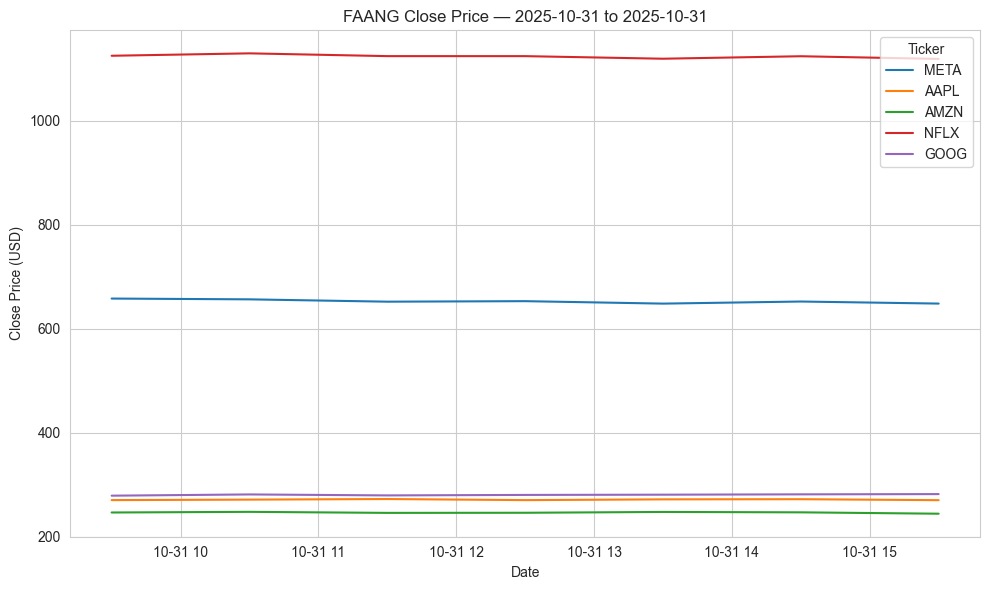

In [21]:
# 🔍 Safely retrieve the `data` dictionary from global scope
data = globals().get('data')

# ❌ Raise an error if `data` is missing, not a dictionary, or empty
if not isinstance(data, dict) or not data:
    raise RuntimeError("❌ No data to plot. Please run Step 2 (`load_latest_data`) to populate the `data` dictionary.")

# 📊 Create a new figure and axis for plotting
fig, ax = plt.subplots(figsize=(10, 6))

# 📅 Store all x-axis values to compute global date range later
all_x = []

# 📈 Loop through each ticker and its corresponding DataFrame
for sym, df in data.items():
    # Skip if the DataFrame is invalid, empty, or missing the 'Close' column
    if not isinstance(df, pd.DataFrame) or df.empty or 'Close' not in df.columns:
        continue

    # 🕒 Determine x-axis values (dates) based on index or 'Date' column
    if isinstance(df.index, pd.DatetimeIndex) and not df.index.empty:
        x = df.index
        y = df['Close']
    elif 'Date' in df.columns:
        # Convert 'Date' column to datetime and filter out invalid entries
        x = pd.to_datetime(df['Date'], errors='coerce')
        valid = x.notna()
        if not valid.any():
            continue
        x = x[valid]
        y = df.loc[valid, 'Close']
    else:
        continue  # Skip if no valid date information is available

    # Skip if y-values are missing or empty
    if y is None or y.empty:
        continue

    # 📉 Plot the close price for this ticker
    ax.plot(x, y, label=sym)

    # Add x-axis values to the global list
    all_x.append(x)

# 🏷️ Add axis labels
ax.set_xlabel('Date')
ax.set_ylabel('Close Price (USD)')

# 📆 Attempt to retrieve global date range from previously defined variables
min_date = globals().get('min_date')
max_date = globals().get('max_date')

# If not available, compute min/max dates from all plotted x-values
if not (isinstance(min_date, pd.Timestamp) and isinstance(max_date, pd.Timestamp)):
    if all_x:
        min_date = min(x.min() for x in all_x)
        max_date = max(x.max() for x in all_x)

# 📝 Add a dynamic title based on the date range
title_range = f"{min_date.date()} to {max_date.date()}" if min_date and max_date else "Latest"
ax.set_title(f"FAANG Close Price — {title_range}")

# 🗂️ Add a legend to identify each ticker
ax.legend(title='Ticker')

# 🧼 Apply tight layout to prevent clipping of labels and titles
fig.tight_layout()


### 💾 Save and Display Plot
Save the plot to the plots/ folder with a timestamped filename and show it inline.

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html — matplotlib.pyplot.savefig

In [22]:
# Try to retrieve the existing timestamp (used when saving the CSV) from the global namespace
ts_local = globals().get('ts')

# If no timestamp exists or it's not a valid string, generate a new one using the current UTC time
if not isinstance(ts_local, str) or not ts_local:
    ts_local = datetime.now(timezone.utc).strftime('%Y%m%d-%H%M%S')

# Define the path to save the plot, using the timestamp as the filename (e.g. '20251106-083000.png')
plot_path = PLOTS_DIR / f'{ts_local}.png'

# Save the figure to the specified path with tight layout to avoid clipping
fig.savefig(plot_path, bbox_inches='tight')

# Print confirmation message with the full path to the saved plot
print(f'✅ Plot saved to {plot_path}')

# Display the plot in the notebook or script output
plt.show()


✅ Plot saved to C:\Users\eCron\OneDrive\Documents\ATU_CourseWork\computer_infrastructure\plots\20251107-123805.png


### 🧪 Diagnostic: Validate Ticker List
This diagnostic step checks the tickers list for duplicates before fetching data.

It helps confirm:

- 📋 The effective list of tickers to be used
- 🔢 Whether any tickers appear more than once
- 🚨 Flags duplicates to prevent redundant downloads or overwrites

This step is useful for debugging and ensuring clean input before running Step 1.

https://realpython.com/python-constants/ — Defining Constants in Python

In [23]:
# Define a function to check for duplicate tickers in the list
def validate_ticker_list(tickers):
    # Print the list of tickers being checked
    print("📋 Effective tickers:", tickers)

    # Count how many times each ticker appears using a Counter
    counts = Counter(tickers)

    # Create a list of tickers that appear more than once
    dups = [t for t, c in counts.items() if c > 1]

    # Print a warning if duplicates are found, otherwise confirm the list is clean
    if dups:
        print(f"⚠️ Duplicate tickers found: {dups}")
    else:
        print("✅ No duplicate tickers detected.")

# Run the diagnostic check on the current ticker list
validate_ticker_list(tickers)


📋 Effective tickers: ['META', 'AAPL', 'AMZN', 'NFLX', 'GOOG']
✅ No duplicate tickers detected.


## ✅ Conclusion

This notebook successfully demonstrates the core learning outcomes of the assessment:

- Hourly FAANG stock data was fetched and saved using `yfinance`.
- Timestamped CSVs and plots were generated and stored in organised directories.
- A standalone CLI script (`faang.py`) was created to automate the workflow.
- The structure supports reproducibility, modularity, and professional readability.

Next steps include integrating the GitHub Actions workflow to automate weekly execution and refining the README for deployment clarity. The repository is designed to be cloned and run with minimal setup, ensuring accessibility for reviewers and future collaborators.